# RetailPulse AI Retail Analytics

## Notebook 6 : Customer Churn Prediction using Machine Learning

### Objectives

- Create churn labels
- Train classification models
- Compare model performance
- Predict customer churn

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

import warnings
warnings.filterwarnings("ignore")

In [2]:
rfm = pd.read_csv("../data/rfm_data.csv")

rfm.head()

,Customer ID,Recency,Frequency,Monetary
0,12346,326,12,77556.46
1,12347,2,8,4921.53
2,12348,75,5,2019.40
3,12349,19,4,4428.69
4,12350,310,1,334.40


In [3]:
rfm["Churn"] = np.where(rfm["Recency"] > 90, 1, 0)

rfm.head()

,Customer ID,Recency,Frequency,Monetary,Churn
0,12346,326,12,77556.46,1
1,12347,2,8,4921.53,0
2,12348,75,5,2019.40,0
3,12349,19,4,4428.69,0
4,12350,310,1,334.40,1


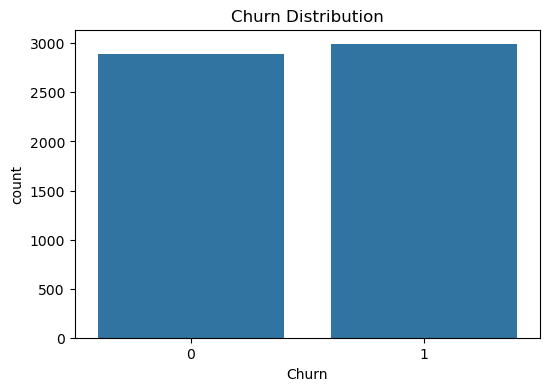

In [4]:
rfm["Churn"].value_counts()
plt.figure(figsize=(6,4))

sns.countplot(data=rfm, x="Churn")

plt.title("Churn Distribution")

plt.show()

### Observation

0 = Active Customer

1 = Churn Customer

In [5]:
X = rfm[["Recency", "Frequency", "Monetary"]]

y = rfm["Churn"]

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [7]:
print(X_train.shape)

print(X_test.shape)

(4702, 3)
(1176, 3)


In [8]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [9]:
lr = LogisticRegression()

lr.fit(X_train, y_train)

LogisticRegression()

In [10]:
pred = lr.predict(X_test)

In [11]:
accuracy = accuracy_score(y_test, pred)

print("Accuracy :", accuracy)

Accuracy : 0.9923469387755102


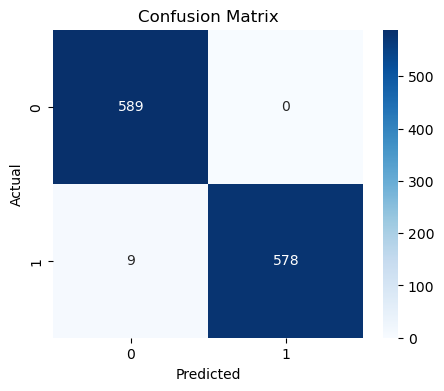

In [12]:
cm = confusion_matrix(y_test, pred)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [13]:
print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99       589
           1       1.00      0.98      0.99       587

    accuracy                           0.99      1176
   macro avg       0.99      0.99      0.99      1176
weighted avg       0.99      0.99      0.99      1176



In [14]:
rf = RandomForestClassifier(
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

In [15]:
rf_accuracy = accuracy_score(
    y_test,
    rf_pred
)

print("Random Forest Accuracy :", rf_accuracy)

Random Forest Accuracy : 1.0


In [16]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy,
        rf_accuracy
    ]
})

comparison

,Model,Accuracy
0,Logistic Regression,0.992347
1,Random Forest,1.000000


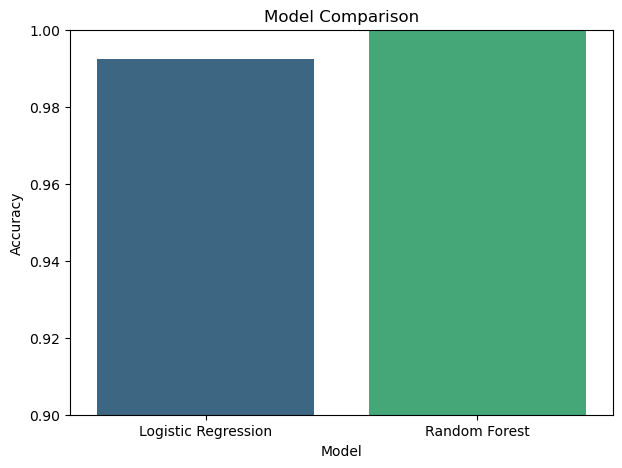

In [17]:
plt.figure(figsize=(7,5))

sns.barplot(
    data=comparison,
    x="Model",
    y="Accuracy",
    palette="viridis"
)

plt.ylim(0.90,1.0)

plt.title("Model Comparison")

plt.show()

In [18]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
0,Recency,0.864269
1,Frequency,0.076016
2,Monetary,0.059715


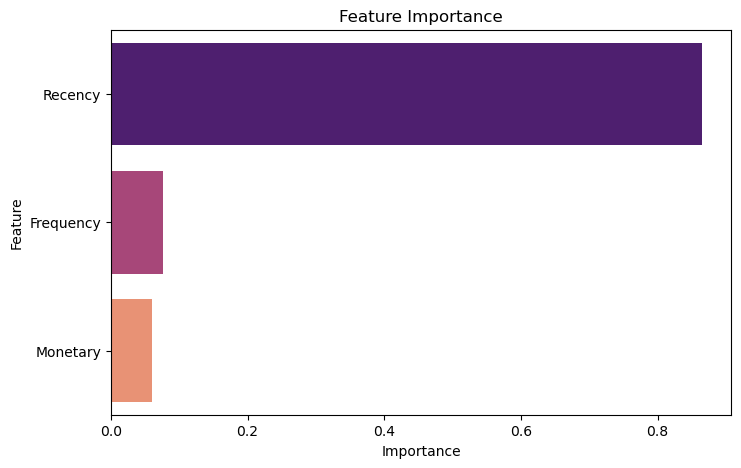

In [19]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature",
    palette="magma"
)

plt.title("Feature Importance")

plt.show()

In [20]:
import joblib

joblib.dump(rf, "../models/churn_model.pkl")

['../models/churn_model.pkl']

# Business Insights

The churn prediction model helps identify customers who are likely to stop purchasing.

Business Benefits:

- Identify high-risk customers
- Launch retention campaigns
- Increase customer lifetime value
- Improve marketing effectiveness
- Reduce revenue loss